In [1]:
import json
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import numpy as np

def plot_metrics(json_paths, exp_names=None):
    """
    json_paths: str o lista[str]
    exp_names: lista[str]
    Tolera distinto número de epochs, usa cmap viridis.
    Pone límite y=[0,1] para precision, recall y f1.
    """

    if isinstance(json_paths, str) or isinstance(json_paths, Path):
        json_paths = [json_paths]

    if exp_names is None:
        exp_names = [Path(p).stem for p in json_paths]

    assert len(exp_names) == len(json_paths), "exp_names debe tener el mismo largo que json_paths"

    n = len(json_paths)
    colors = cm.viridis(np.linspace(0, 1, n))

    plt.figure(figsize=(12, 8))

    metric_keys = ["clip_val_loss", "val_precision", "val_recall", "val_f1"]
    titles = ["Validation Loss", "Macro-Precision", "Macro-Recall", "Macro-F1 Score"]

    for idx, (json_path, exp_name) in enumerate(zip(json_paths, exp_names)):
        epochs, values = [], {k: [] for k in metric_keys}

        # Leer NDJSON
        with open(json_path, "r") as f:
            for line in f:
                d = json.loads(line.strip())
                epochs.append(d.get("epoch"))
                for k in metric_keys:
                    values[k].append(d.get(k, None))

        # Graficar
        for i, k in enumerate(metric_keys, start=1):
            ax = plt.subplot(2, 2, i)
            ax.plot(epochs, values[k], label=exp_name, color=colors[idx])
            ax.set_title(titles[i-1])
            ax.set_xlabel("Epoch")

            # Limitar ejes solo para métricas 0-1
            #if k != "clip_val_loss":
            #    ax.set_ylim(0.0, 1.0)

            ax.grid(True, linestyle=":", linewidth=1, alpha=0.4)
            ax.legend()

    plt.tight_layout()
    plt.show()


In [2]:
def plot_metrics(json_paths, exp_names=None):
    if isinstance(json_paths, (str, Path)):
        json_paths = [json_paths]

    if exp_names is None:
        exp_names = [Path(p).stem for p in json_paths]

    n = len(json_paths)
    colors = cm.viridis(np.linspace(0, 1, n))

    plt.figure(figsize=(12, 10))
    metric_keys = ["clip_val_loss", "val_precision", "val_recall", "val_f1"]
    titles = ["Validation Loss", "Macro-Precision", "Macro-Recall", "Macro-F1 Score"]

    # --- Configuración de la Tabla ---
    # Definimos el encabezado dinámicamente
    header = f"{'Experimento':<40} | {'Loss (min)':<15} | {'Prec (max)':<15} | {'Rec (max)':<15} | {'F1 (max)':<15}"
    print(header)
    print("-" * len(header))

    for idx, (json_path, exp_name) in enumerate(zip(json_paths, exp_names)):
        epochs, values = [], {k: [] for k in metric_keys}

        with open(json_path, "r") as f:
            for line in f:
                d = json.loads(line.strip())
                epochs.append(d.get("epoch"))
                for k in metric_keys:
                    values[k].append(d.get(k))

        # Diccionario para guardar los mejores de cada métrica en este experimento
        best_stats = {}
        eps = np.array(epochs)

        for k in metric_keys:
            vals = np.array(values[k], dtype=float)
            # Para loss buscamos el mínimo, para el resto el máximo
            if "loss" in k:
                best_idx = np.nanargmin(vals)
            else:
                best_idx = np.nanargmax(vals)
            
            best_stats[k] = (eps[best_idx], vals[best_idx])

        # --- Imprimir fila de la tabla ---
        row = f"{exp_name[:40]:<40}"
        for k in metric_keys:
            ep, val = best_stats[k]
            row += f" | E{int(ep):>2}: {val:.4f}"
        print(row)

        # --- Graficar ---
        for i, k in enumerate(metric_keys, start=1):
            ax = plt.subplot(2, 2, i)
            ax.plot(epochs, values[k], label=exp_name, color=colors[idx], linewidth=2)
            
            # Marcar el punto óptimo en cada gráfico
            best_ep, best_val = best_stats[k]
            ax.scatter(best_ep, best_val, color=colors[idx], edgecolors='black', s=40, zorder=5)
                
            ax.set_title(titles[i-1])
            ax.set_xlabel("Epoch")
            ax.grid(True, linestyle=":", linewidth=1, alpha=0.4)
            if idx == len(json_paths) - 1:
                ax.legend(loc='best')

    plt.tight_layout()
    plt.show()

In [3]:
def plot_metrics_step_5(json_paths, exp_names=None):
    if isinstance(json_paths, (str, Path)):
        json_paths = [json_paths]

    if exp_names is None:
        exp_names = [Path(p).stem for p in json_paths]

    n = len(json_paths)
    colors = cm.viridis(np.linspace(0, 1, n))

    plt.figure(figsize=(12, 10))
    metric_keys = ["clip_val_loss", "val_precision", "val_recall", "val_f1"]
    titles = ["Validation Loss", "Macro-Precision", "Macro-Recall", "Macro-F1 Score"]

    header = f"{'Experimento':<40} | {'Loss (min@5e)':<15} | {'Prec (max@5e)':<15} | {'Rec (max@5e)':<15} | {'F1 (max@5e)':<15}"
    print(header)
    print("-" * len(header))

    for idx, (json_path, exp_name) in enumerate(zip(json_paths, exp_names)):
        all_epochs, all_values = [], {k: [] for k in metric_keys}

        with open(json_path, "r") as f:
            for line in f:
                d = json.loads(line.strip())
                all_epochs.append(d.get("epoch"))
                for k in metric_keys:
                    all_values[k].append(d.get(k))

        # --- FILTRADO: Solo múltiplos de 5 ---
        # Creamos listas que solo contienen los datos de las épocas 5, 10, 15...
        filtered_indices = [i for i, ep in enumerate(all_epochs) if int(ep) % 5 == 0 and ep != 0]
        
        f_epochs = np.array([all_epochs[i] for i in filtered_indices])
        f_values = {k: np.array([all_values[k][i] for i in filtered_indices]) for k in metric_keys}

        best_stats = {}
        for k in metric_keys:
            vals = f_values[k]
            if len(vals) == 0: continue # Por si no ha llegado a la época 5
            
            if "loss" in k:
                best_idx = np.nanargmin(vals)
            else:
                best_idx = np.nanargmax(vals)
            
            best_stats[k] = (f_epochs[best_idx], vals[best_idx])

        # --- Imprimir fila (basada en el filtro de 5 en 5) ---
        row = f"{exp_name[:40]:<40}"
        for k in metric_keys:
            if k in best_stats:
                ep, val = best_stats[k]
                row += f" | E{int(ep):>2}: {val:.4f}"
            else:
                row += " | N/A"
        print(row)

        # --- Graficar ---
        for i, k in enumerate(metric_keys, start=1):
            ax = plt.subplot(2, 2, i)
            # Graficamos la línea completa para no perder el contexto visual
            ax.plot(all_epochs, all_values[k], label=exp_name, color=colors[idx], linewidth=1.5, alpha=1)
            # Graficamos los puntos de cada 5 épocas más marcados
            ax.scatter(f_epochs, f_values[k], color=colors[idx], s=15, alpha=0.6)
            
            # Resaltamos el mejor de los múltiplos de 5
            if k in best_stats:
                best_ep, best_val = best_stats[k]
                ax.scatter(best_ep, best_val, color=colors[idx], edgecolors='black', s=150, zorder=10, marker='*')
                
            ax.set_title(titles[i-1])
            ax.set_xlabel("Epoch")
            ax.grid(True, linestyle=":", linewidth=1, alpha=0.4)
            if idx == len(json_paths) - 1:
                ax.legend(loc='best')

    plt.tight_layout()
    plt.show()

Experimento                              | Loss (min@5e)   | Prec (max@5e)   | Rec (max@5e)    | F1 (max@5e)    
----------------------------------------------------------------------------------------------------------------
ViT-B-16 fp16                            | E15: 3.6468 | E95: 0.7766 | E35: 0.8982 | E95: 0.8124
ViT-B-16 fp32 + trivial + taxo           | E15: 3.0155 | E90: 0.7901 | E60: 0.8896 | E90: 0.8203


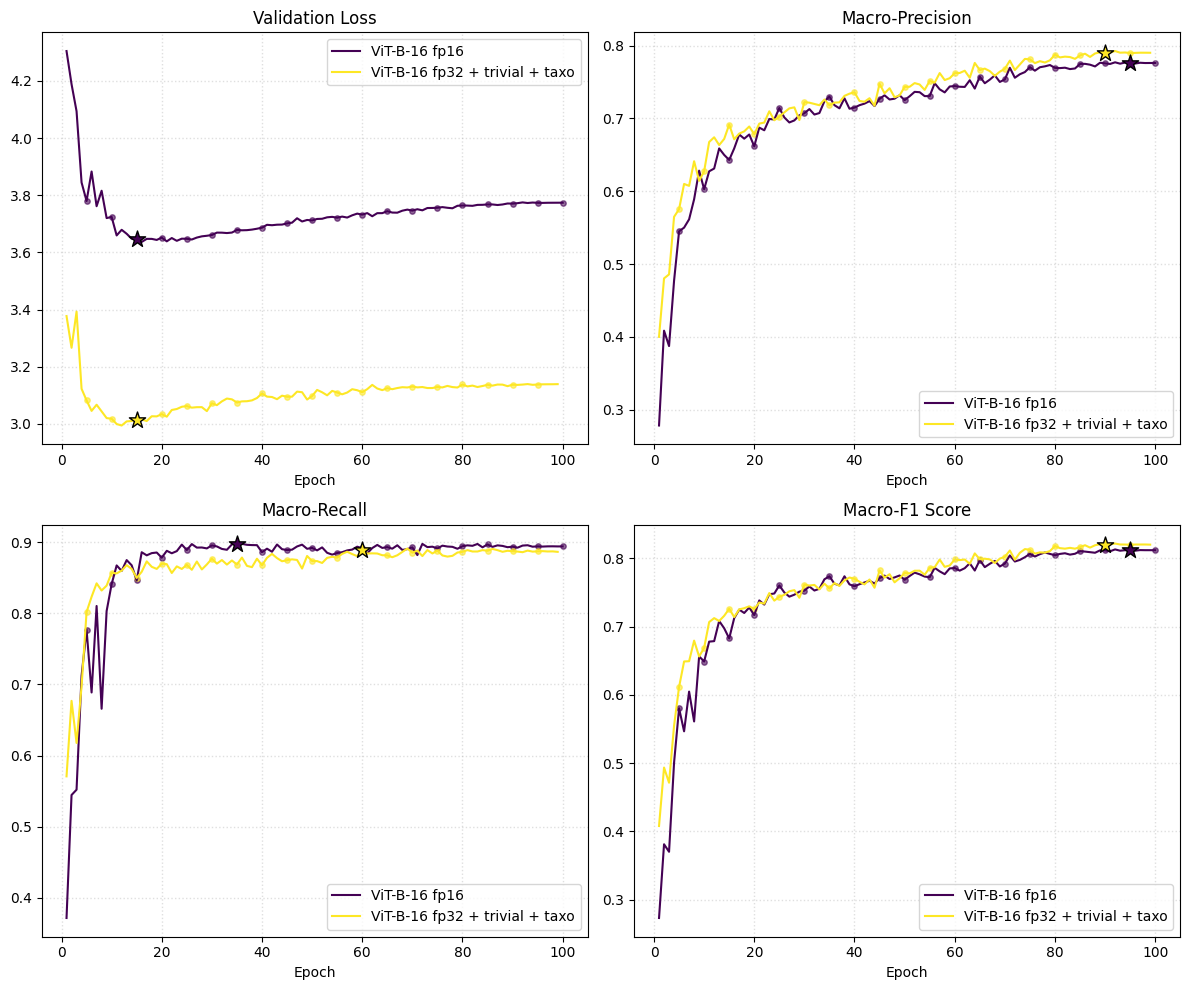

In [5]:
json_paths =[
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_02_27-06_43_55-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
    #"/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_21-17_14_09-model_ViT-B-16-lr_0.0001-b_256-j_4-p_fp32/checkpoints/results.jsonl",
    #"/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_21-18_14_31-model_ViT-B-16-lr_0.0001-b_256-j_4-p_fp32/checkpoints/results.jsonl",
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_21-18_16_30-model_ViT-B-16-lr_0.0001-b_256-j_4-p_fp32/checkpoints/results.jsonl",

]

exp_names =[
    "ViT-B-16 fp16",
    #"ViT-B-16 fp32",
    #"ViT-B-16 fp32 + trivial",
    "ViT-B-16 fp32 + trivial + taxo",
    ]

plot_metrics_step_5(json_paths, exp_names)

Experimento                              | Loss (min@5e)   | Prec (max@5e)   | Rec (max@5e)    | F1 (max@5e)    
----------------------------------------------------------------------------------------------------------------
ViT-B-16 fp16 (1)                        | E15: 3.6468 | E95: 0.7766 | E35: 0.8982 | E95: 0.8124
ViT-B-16 fp16 (2)                        | E30: 3.6322 | E95: 0.7669 | E65: 0.9034 | E95: 0.8081
ViT-B-16 fp32                            | E20: 2.9823 | E45: 0.7344 | E30: 0.8976 | E45: 0.7793
ViT-B-16 fp32 + trivial                  | E10: 3.0071 | E40: 0.7273 | E30: 0.8801 | E40: 0.7673
ViT-B-16 fp32 + trivial + taxo           | E15: 3.0155 | E30: 0.7224 | E30: 0.8769 | E30: 0.7616


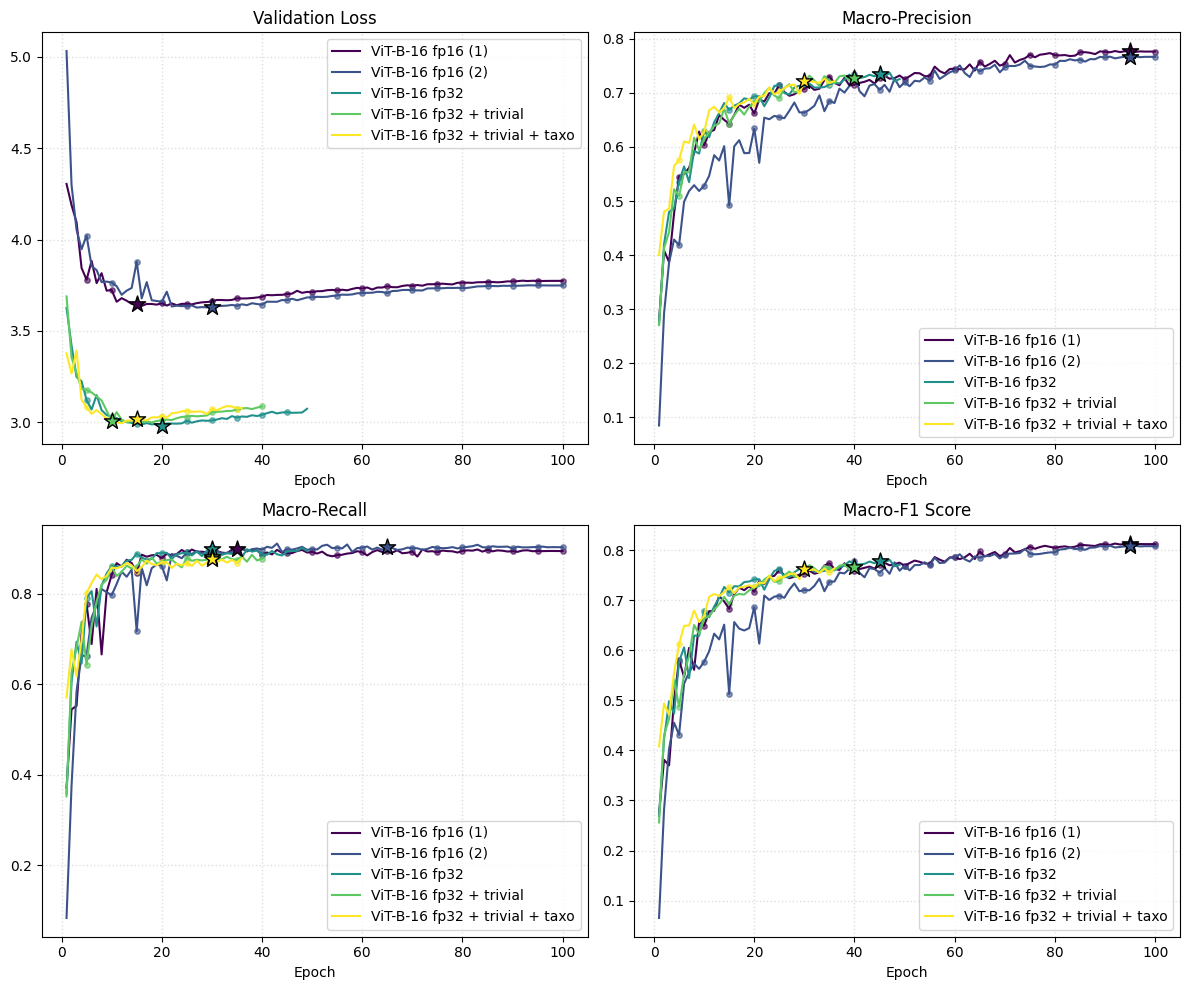

In [6]:
json_paths =[
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_02_27-06_43_55-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-15_34_50-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_21-17_14_09-model_ViT-B-16-lr_0.0001-b_256-j_4-p_fp32/checkpoints/results.jsonl",
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_21-18_14_31-model_ViT-B-16-lr_0.0001-b_256-j_4-p_fp32/checkpoints/results.jsonl",
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_21-18_16_30-model_ViT-B-16-lr_0.0001-b_256-j_4-p_fp32/checkpoints/results.jsonl",

]

exp_names =[
    "ViT-B-16 fp16 (1)",
    "ViT-B-16 fp16 (2)",
    "ViT-B-16 fp32",
    "ViT-B-16 fp32 + trivial",
    "ViT-B-16 fp32 + trivial + taxo",
    ]

plot_metrics_step_5(json_paths, exp_names)

Experimento                              | Loss (min@5e)   | Prec (max@5e)   | Rec (max@5e)    | F1 (max@5e)    
----------------------------------------------------------------------------------------------------------------
ViT-B-16 16k                             | E15: 3.6468 | E95: 0.7766 | E35: 0.8982 | E95: 0.8124
ViT-B-16 16k 2                           | E30: 3.6322 | E95: 0.7669 | E65: 0.9034 | E95: 0.8081


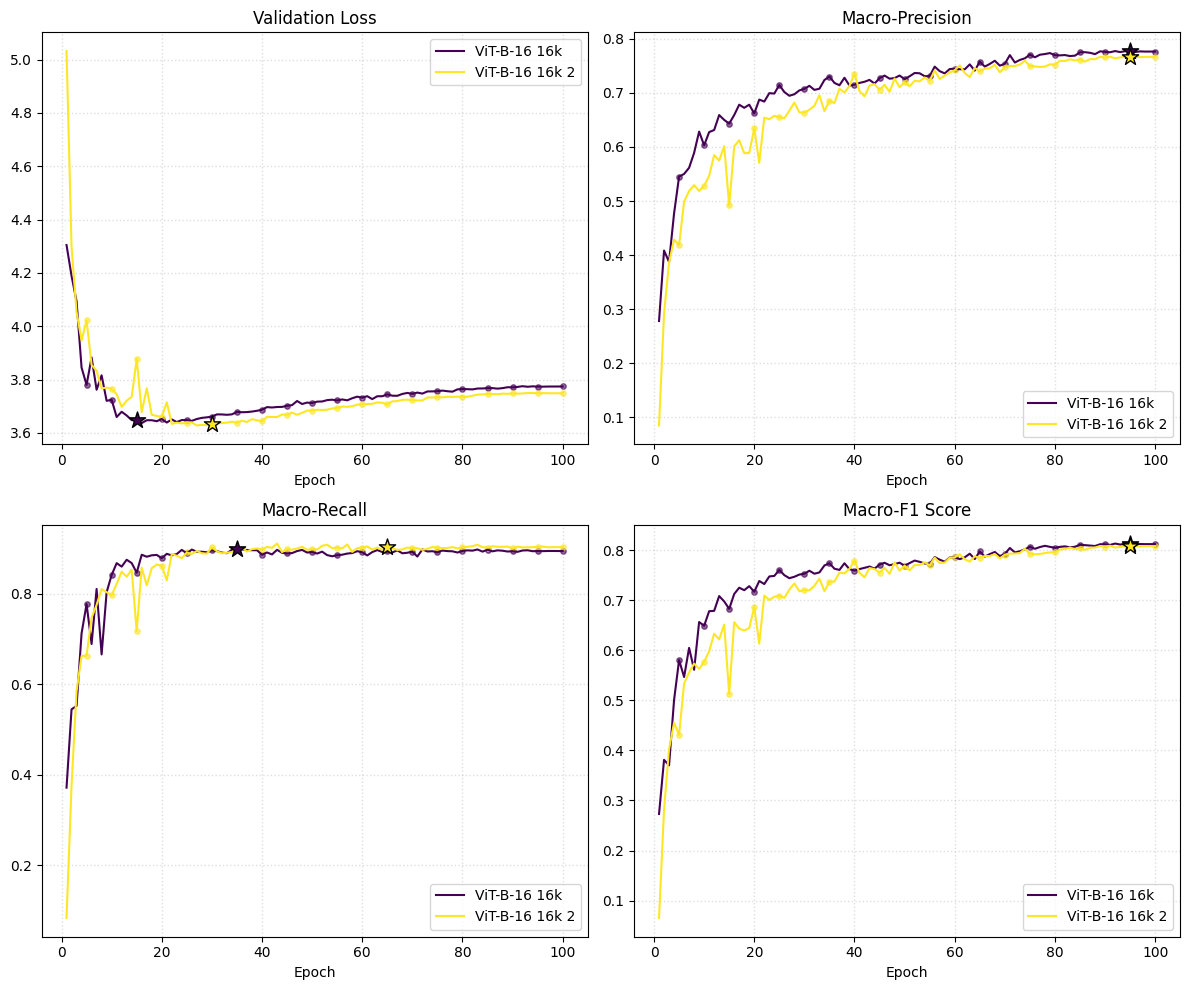

In [18]:
json_paths =[
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_02_27-06_43_55-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-15_34_50-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl"

]

exp_names =[
    "ViT-B-16 16k",
    "ViT-B-16 16k 2",
    ]

plot_metrics_step_5(json_paths, exp_names)

Experimento                              | Loss (min@5e)   | Prec (max@5e)   | Rec (max@5e)    | F1 (max@5e)    
----------------------------------------------------------------------------------------------------------------
ViT-B-16 16k                             | E30: 3.6322 | E95: 0.7669 | E65: 0.9034 | E95: 0.8081
BioCLIP 16k                              | E50: 3.6774 | E95: 0.7015 | E95: 0.8809 | E95: 0.7529
BioCLIP2 16k                             | E15: 2.9883 | E90: 0.8150 | E35: 0.9032 | E90: 0.8444
ViT-L-14 16k                             | E15: 2.9750 | E90: 0.8180 | E20: 0.9082 | E90: 0.8490


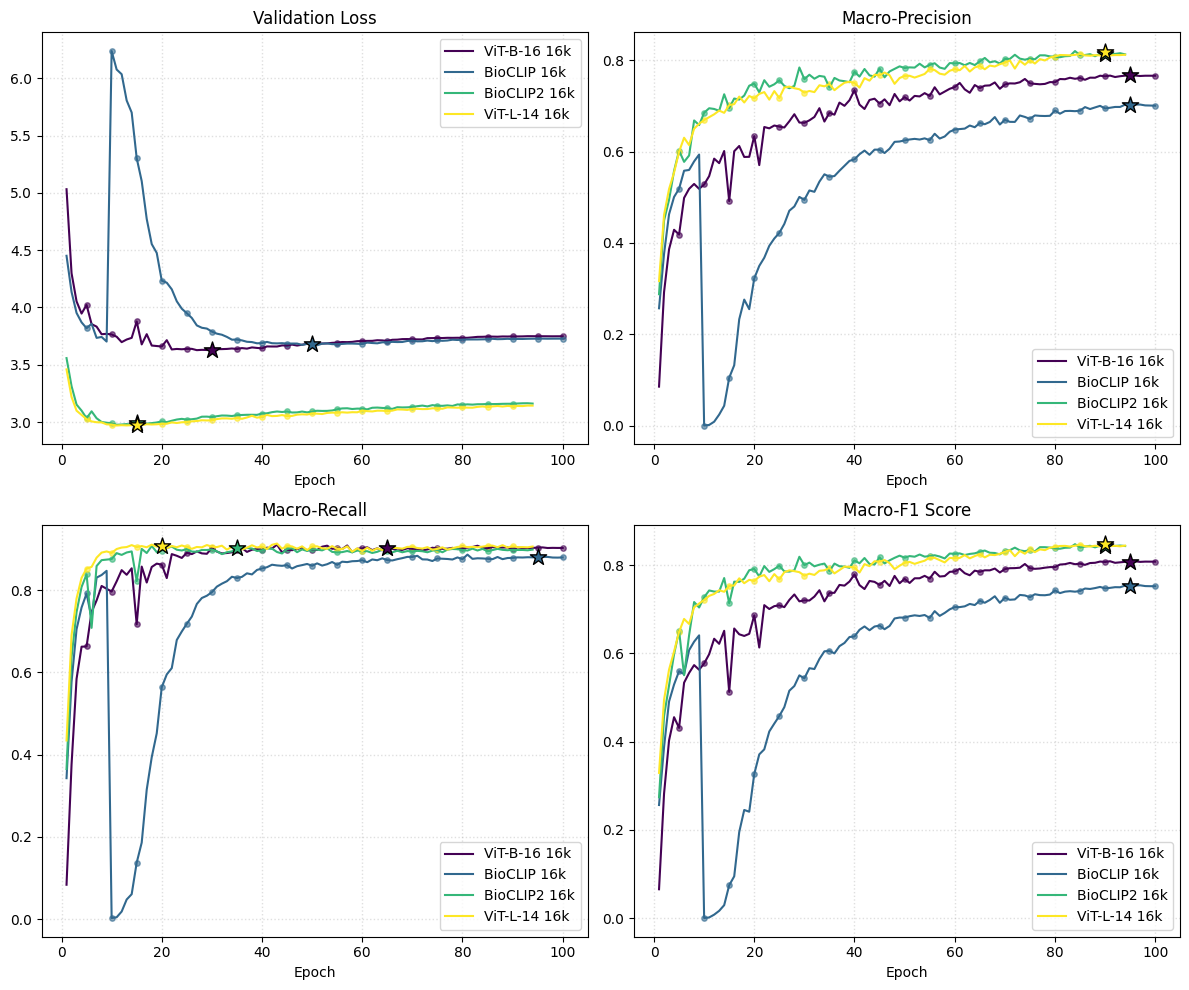

In [22]:
json_paths =[
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-15_34_50-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_02_27-06_51_03-model_hf-hub:imageomics-bioclip-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_03-21_40_32-model_ViT-L-14-lr_0.0001-b_256-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_03-21_40_52-model_hf-hub:imageomics-bioclip-2-lr_0.0001-b_256-j_4-p_amp/checkpoints/results.jsonl"

]

exp_names =[
    "ViT-B-16 16k",
    "BioCLIP 16k",
    "BioCLIP2 16k",
    "ViT-L-14 16k",

    ]

plot_metrics_step_5(json_paths, exp_names)

Experimento                              | Loss (min@5e)   | Prec (max@5e)   | Rec (max@5e)    | F1 (max@5e)    
----------------------------------------------------------------------------------------------------------------
ViT-B-16 16k no aug                      | E10: 3.0324 | E100: 0.7659 | E75: 0.8600 | E100: 0.7887
ViT-B-16 16k aug                         | E15: 3.6468 | E95: 0.7766 | E35: 0.8982 | E95: 0.8124
ViT-B-16 512 no aug                      | E15: 0.5297 | E40: 0.6327 | E30: 0.7773 | E40: 0.6515
ViT-B-16 512 aug                         | E15: 0.5071 | E35: 0.6427 | E35: 0.8130 | E35: 0.6713


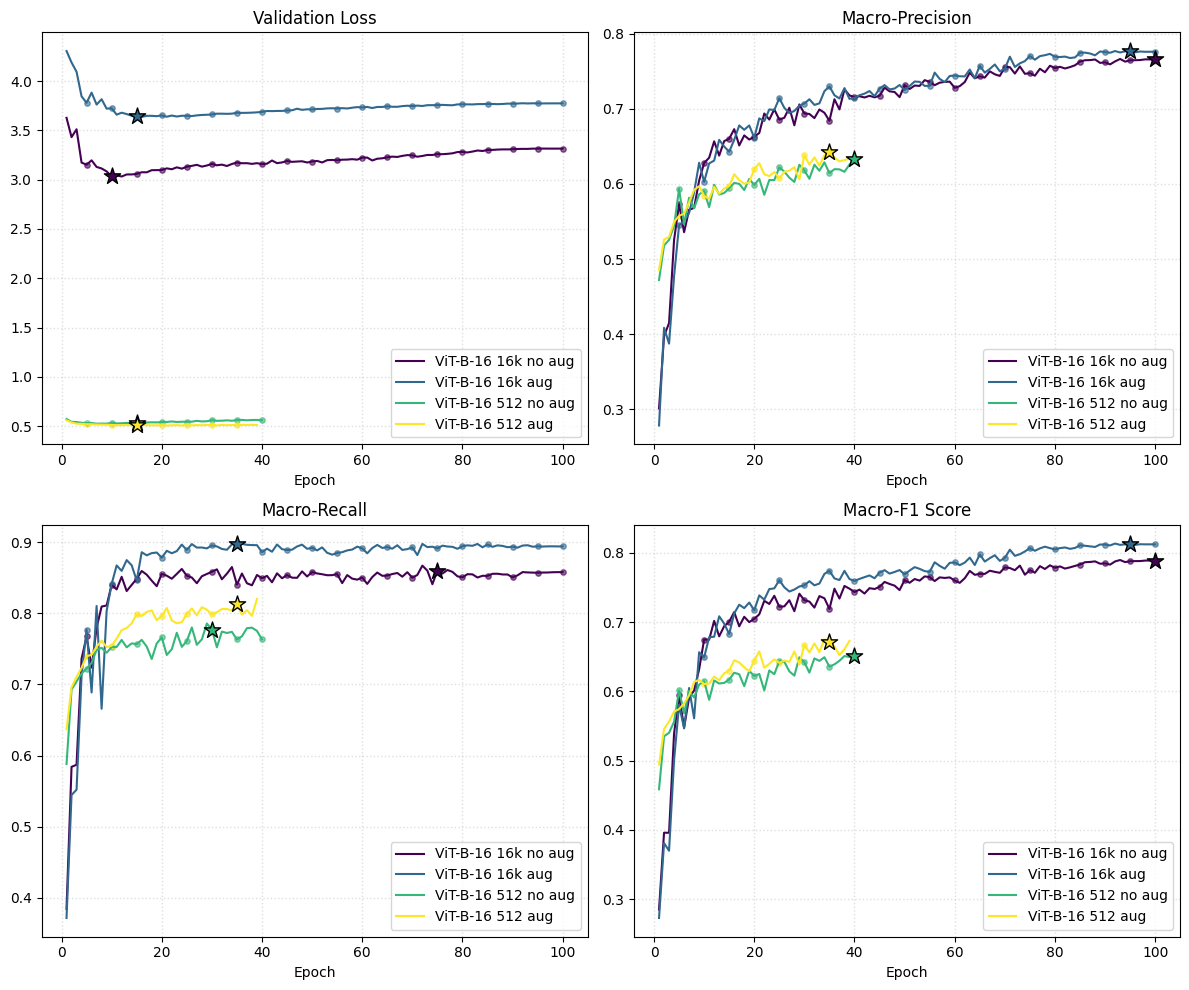

In [20]:
json_paths =[
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-04_01_50-model_ViT-B-16-lr_0.0001-b_256-j_4-p_amp/checkpoints/results.jsonl",
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_02_27-06_43_55-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-04_02_49-model_ViT-B-16-lr_0.0001-b_8-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-04_02_59-model_ViT-B-16-lr_0.0001-b_8-j_4-p_amp/checkpoints/results.jsonl",

]

exp_names =[
    "ViT-B-16 16k no aug",
    "ViT-B-16 16k aug",
    "ViT-B-16 512 no aug",
    "ViT-B-16 512 aug",

    ]

plot_metrics_step_5(json_paths, exp_names)

Experimento                              | Loss (min)      | Prec (max)      | Rec (max)       | F1 (max)       
----------------------------------------------------------------------------------------------------------------
ViT-B-16 16K aug                         | E16: 3.6367 | E92: 0.7771 | E35: 0.8982 | E92: 0.8132
ViT-B-16 32K aug                         | E27: 3.6277 | E95: 0.7669 | E43: 0.9107 | E91: 0.8089


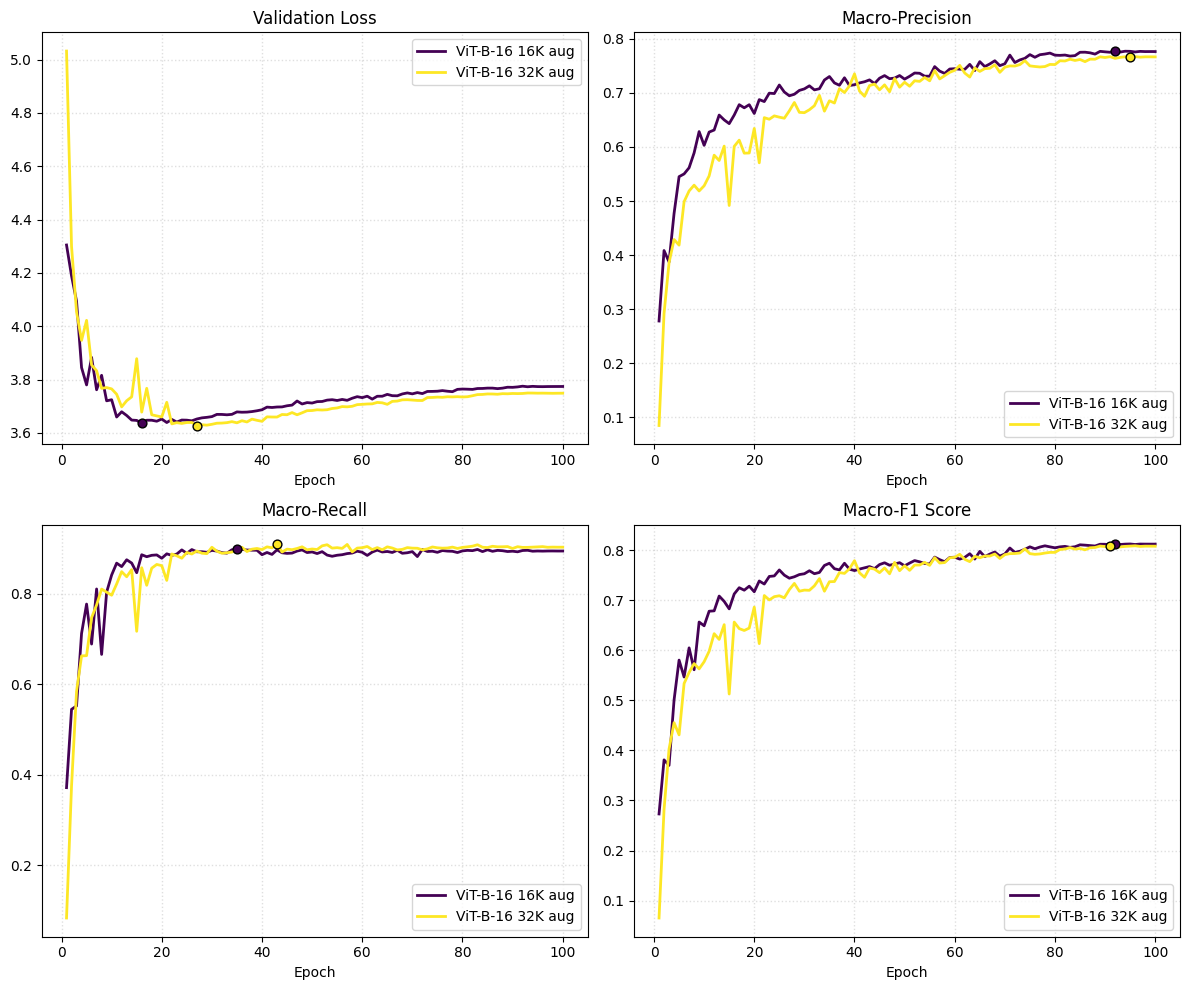

In [21]:
json_paths =[
    "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_02_27-06_43_55-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",
   "/lustre/fswork/projects/rech/tec/uod68bo/am/open_clip/logs/2026_03_16-15_34_50-model_ViT-B-16-lr_0.0001-b_512-j_4-p_amp/checkpoints/results.jsonl",


]

exp_names =[
    "ViT-B-16 16K aug",
    "ViT-B-16 32K aug",

    ]

plot_metrics(json_paths, exp_names)